# Notebook 3 — RNN: Feature Extraction, Preprocessing & Training

## 1 Setup

In [1]:
import os
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'
os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'
os.environ['TF_CUDNN_USE_AUTOTUNE'] = '0'

In [2]:
from pathlib import Path
import json, random, sys, time

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebook":
    PROJECT_ROOT = PROJECT_ROOT.parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.wajib.rnn.RNN import buildRNNKeras, trainRNNKeras, trainRNNDataset, RNNScratch
from src.wajib.shared.layers import EmbeddingLayer, DenseLayer
from src.wajib.shared.preprocessing import (
    loadFlickr8kCaptions, buildVocabulary, saveVocabulary, loadVocabulary,
)
from src.wajib.shared.decoder import greedyDecode
from nltk.translate.bleu_score import sentence_bleu, corpus_bleu

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)
print("GPUs:", gpus)

I0000 00:00:1778845067.912938   70270 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2 Config

In [3]:
FEATURES_NPY  = PROJECT_ROOT / "src/wajib/weights/features/flickr8k_features.npy"
FEATURES_IDX  = PROJECT_ROOT / "src/wajib/weights/features/flickr8k_index.json"
CAPTIONS_FILE = PROJECT_ROOT / "data/flickr8k/captions.txt"
VOCAB_PATH    = PROJECT_ROOT / "src/wajib/weights/vocab.json"
WEIGHTS_DIR   = PROJECT_ROOT / "src/wajib/weights/rnn"
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)

EMBED_DIM    = 256
MAX_LEN      = 30
EPOCHS       = 5
BATCH_SIZE   = 64
CNN_FEAT_DIM = 2048

# 3 variasi num_layers × 2 variasi hidden_dim = 6 total
VARIATIONS = [
    (1, 128),
    (1, 512),
    (2, 128),
    (2, 512),
    (3, 128),
    (3, 512),
]

### 3 Load CNN Features

In [4]:
features_matrix = np.load(FEATURES_NPY)
with open(FEATURES_IDX) as f:
    idx_names = json.load(f)

image_features = {name: features_matrix[i] for i, name in enumerate(idx_names)}
print(f"Loaded {len(image_features)} features, dim={features_matrix.shape[1]}")

Loaded 8091 features, dim=2048


### 4 Load Captions + Split + Vocab

In [5]:
captions_dict = loadFlickr8kCaptions(str(CAPTIONS_FILE))

all_images = list(captions_dict.keys())
random.shuffle(all_images)  # seed already set in cell 1

train_imgs = set(all_images[:6000])
val_imgs   = set(all_images[6000:7000])
test_imgs  = set(all_images[7000:])

train_caps = {k: v for k, v in captions_dict.items() if k in train_imgs}
val_caps   = {k: v for k, v in captions_dict.items() if k in val_imgs}
test_caps  = {k: v for k, v in captions_dict.items() if k in test_imgs}

print(f"Split => train={len(train_caps)}, val={len(val_caps)}, test={len(test_caps)}")

if VOCAB_PATH.exists():
    vocab = loadVocabulary(str(VOCAB_PATH))
    print(f"Vocab loaded: {len(vocab)}")
else:
    all_train_caps = [cap for caps in train_caps.values() for cap in caps]
    vocab = buildVocabulary(all_train_caps, min_freq=2)
    saveVocabulary(vocab, str(VOCAB_PATH))
    print(f"Vocab built + saved: {len(vocab)}")

Split => train=6000, val=1000, test=1091
Vocab loaded: 4558


### 5 Build Dataset Arrays

In [6]:
X_cnn_tr, X_tok_tr, y_tr = trainRNNDataset(image_features, train_caps, vocab, MAX_LEN)
X_cnn_va, X_tok_va, y_va = trainRNNDataset(image_features, val_caps,   vocab, MAX_LEN)

print(f"Train -> X_cnn={X_cnn_tr.shape}, X_tok={X_tok_tr.shape}, y={y_tr.shape}")
print(f"Val   -> X_cnn={X_cnn_va.shape}, X_tok={X_tok_va.shape}, y={y_va.shape}")

Train -> X_cnn=(30000, 2048), X_tok=(30000, 30), y=(30000, 31)
Val   -> X_cnn=(5000, 2048), X_tok=(5000, 30), y=(5000, 31)


### 6 Training (6 Variation)

In [7]:
histories = {}

for i, (num_layers, hidden_dim) in enumerate(VARIATIONS):
    name      = f"rnn_{num_layers}L_{hidden_dim}h"
    save_path = WEIGHTS_DIR / f"{name}.keras"

    print(f"\n{'='*50}\n  {name}\n{'='*50}")

    model = buildRNNKeras(
        vocab_size     = len(vocab),
        embed_dim      = EMBED_DIM,
        hidden_dim     = hidden_dim,
        num_rnn_layers = num_layers,
        cnn_feature_dim= CNN_FEAT_DIM,
        rnn_type = 'rnn'
    )
    if i == 0:
        model.summary()

    hist = trainRNNKeras(
        model,
        X_cnn_tr, X_tok_tr, y_tr,
        X_cnn_va, X_tok_va, y_va,
        epochs     = EPOCHS,
        batch_size = BATCH_SIZE,
        save_path  = str(save_path),
    )
    histories[name] = hist
    print(f"  Saved to {save_path.name}")

print(f"\nSemua {len(VARIATIONS)} variasi selesai.")


  rnn_1L_128h


I0000 00:00:1778845101.500677   70270 gpu_process_state.cc:208] Using CUDA malloc Async allocator for GPU: 0
I0000 00:00:1778845101.503227   70270 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2605 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ cnn_feature         │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_ids           │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_proj (Dense)    │ (None, 256)       │    524,544 │ cnn_feature[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, None, 256) │  1,166,848 │ token_ids[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, None)      │          0 │ token_ids[0][0]   │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 256)    │          0 │ cnn_proj[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expand_dims         │ (None, None, 1)   │          0 │ not_equal[0][0]   │
│ (ExpandDims)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zeros_like          │ (None, None, 256) │          0 │ embedding[0][0]   │
│ (ZerosLike)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ones_like           │ (None, 1, 256)    │          0 │ reshape[0][0]     │
│ (OnesLike)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ logical_or          │ (None, None, 256) │          0 │ expand_dims[0][0… │
│ (LogicalOr)         │                   │            │ zeros_like[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, None, 256) │          0 │ ones_like[0][0],  │
│ (Concatenate)       │                   │            │ logical_or[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, None, 256) │          0 │ reshape[0][0],    │
│ (Concatenate)       │                   │            │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any (Any)           │ (None, None)      │          0 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rnn_0 (SimpleRNN)   │ (None, None, 128) │     49,280 │ concatenate[0][0… │
│                     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, None, 128) │          0 │ rnn_0[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, None,      │    587,982 │ dropout[0][0]     │
│                     │ 4558)             │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,328,654 (8.88 MB)

...

469/469 ━━━━━━━━━━━━━━━━━━━━ 34s 42ms/step - loss: 4.5708 - val_loss: 3.8712
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - loss: 3.7588 - val_loss: 3.5296
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - loss: 3.5360 - val_loss: 3.3876
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - loss: 3.4140 - val_loss: 3.3006
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - loss: 3.3288 - val_loss: 3.2372
  Saved to rnn_3L_128h.keras

  rnn_3L_512h
Epoch 1/5


I0000 00:00:1778845631.869101   70845 dot_merger.cc:481] Merging Dots in computation: functional_5_1_rnn_2_1_while_body_69989_grad_70273_const_0__.35.clone.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1778845631.869268   70845 dot_merger.cc:481] Merging Dots in computation: functional_5_1_rnn_1_1_while_body_69827_grad_70613_const_0__.41.clone.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1778845631.869395   70845 dot_merger.cc:481] Merging Dots in computation: functional_5_1_rnn_0_1_while_body_69665_grad_70953_const_0__.47.clone.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1778845631.869510   70845 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_71794__.53


468/469 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 4.5879

I0000 00:00:1778845666.920383   70840 dot_merger.cc:481] Merging Dots in computation: functional_5_1_rnn_2_1_while_body_69989_grad_70273_const_0__.35.clone.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1778845666.920597   70840 dot_merger.cc:481] Merging Dots in computation: functional_5_1_rnn_1_1_while_body_69827_grad_70613_const_0__.41.clone.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1778845666.920726   70840 dot_merger.cc:481] Merging Dots in computation: functional_5_1_rnn_0_1_while_body_69665_grad_70953_const_0__.47.clone.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1778845666.920874   70840 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_71794__.53


469/469 ━━━━━━━━━━━━━━━━━━━━ 59s 90ms/step - loss: 4.0522 - val_loss: 3.4630
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 29s 62ms/step - loss: 3.3868 - val_loss: 3.2155
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 30s 63ms/step - loss: 3.1791 - val_loss: 3.0947
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 32s 67ms/step - loss: 3.0507 - val_loss: 3.0340
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 31s 65ms/step - loss: 2.9599 - val_loss: 2.9928
  Saved to rnn_3L_512h.keras

Semua 6 variasi selesai.


### Training and Loss Curve

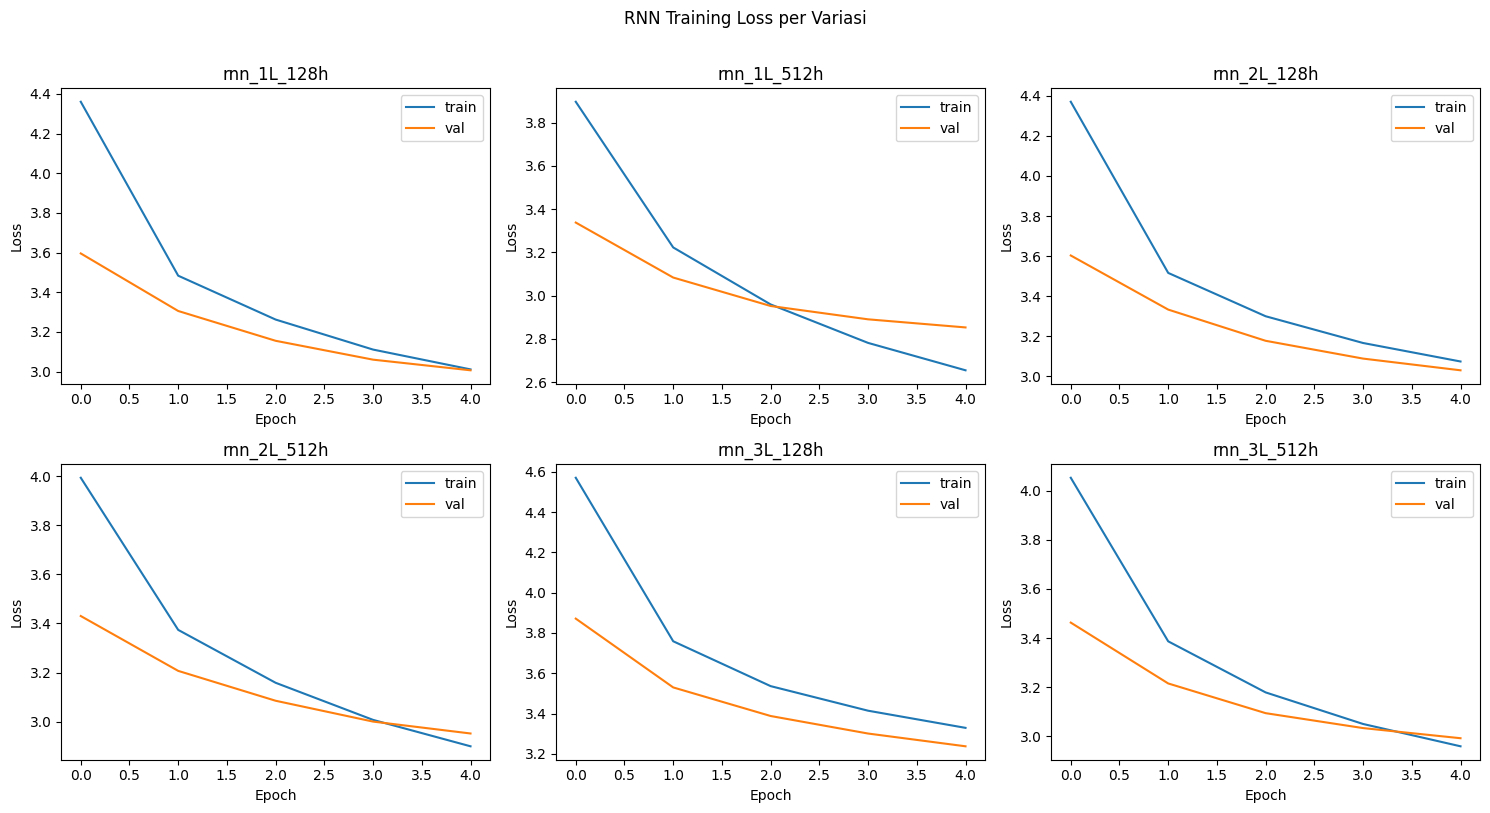

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, (name, hist) in zip(axes.flatten(), histories.items()):
    ax.plot(hist['loss'],     label='train')
    ax.plot(hist['val_loss'], label='val')
    ax.set_title(name)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()

plt.suptitle("RNN Training Loss per Variasi", y=1.01)
plt.tight_layout()
plt.savefig(WEIGHTS_DIR / "rnn_training_curves.png", dpi=150, bbox_inches='tight')
plt.show()

### Training Summary

In [9]:
print(f"{'Model':<22} {'Best Val Loss':>14} {'Epochs':>7}")
print('-' * 45)
for name, hist in histories.items():
    print(f"{name:<22} {min(hist['val_loss']):>14.4f} {len(hist['val_loss']):>7}")

best_name   = min(histories, key=lambda n: min(histories[n]['val_loss']))
best_layers = int(best_name.split('L')[0].split('_')[1])
print(f"\nBest: {best_name}")

Model                   Best Val Loss  Epochs
---------------------------------------------
rnn_1L_128h                    3.0063       5
rnn_1L_512h                    2.8529       5
rnn_2L_128h                    3.0301       5
rnn_2L_512h                    2.9516       5
rnn_3L_128h                    3.2372       5
rnn_3L_512h                    2.9928       5

Best: rnn_1L_512h
